### Michele Pavanello & Valeria Rios Vargas - May 11, 2025

### We use [ASE](https://wiki.fysik.dtu.dk/ase/) for bulding systems. [DFTpy](https://dftpy.rutgers.edu/) for evaluating functionals.

## Import some modules

In [41]:
from dftpy.ions import Ions
from dftpy.field import DirectField
from dftpy.grid import DirectGrid
from dftpy.functional import LocalPseudo, Functional, TotalFunctional
from dftpy.formats import io
from dftpy.math_utils import ecut2nr
from dftpy.time_data import TimeData
from dftpy.optimization import Optimization
from dftpy.mpi import sprint

In [42]:
import matplotlib.pyplot as plt
import numpy as np

### Let's suppress the dftpy log. Set to 2 if needed.

In [43]:
from dftpy.constants import environ
environ['LOGLEVEL']=4

## Locate PPs files and a `Function` to list them
We use the OEPP pseudopotentials by [Mi et al.](https://pubs.aip.org/aip/jcp/article/144/13/134108/152212/First-principle-optimal-local-pseudopotentials)

In [44]:
path_pp = "./OEPP_lib/OEPP/RECPOT/"

In [45]:
def get_atoms(folder_path):
    import os
    prefixes = []
    for filename in os.listdir(folder_path):
        if os.path.isfile(os.path.join(folder_path, filename)):
            if "_" in filename:
                prefix = filename.split("_")[0]
                prefixes.append(prefix)
    return prefixes

In [46]:
!ls ./OEPP_lib/OEPP/RECPOT/

Ag_lda.oe01.recpot Cd_lda.oe01.recpot K_lda.oe01.recpot  Se_lda.oe01.recpot
Al_lda.oe01.recpot Cs_lda.oe02.recpot Li_lda.oe02.recpot Si_lda.oe01.recpot
As_lda.oe04.recpot Ga_lda.oe04.recpot Mg_lda.oe01.recpot Sn_lda.oe04.recpot
Ba_lda.oe01.recpot Ge_lda.oe02.recpot Na_lda.oe02.recpot Sr_lda.oe1.recpot
Be_lda.oe02.recpot Hg_lda.oe01.recpot P_lda.oe01.recpot  Te_lda.oe03.recpot
Br_lda.oe01.recpot I_lda.oe01.recpot  S_lda.oe01.recpot  Zn_lda.oe03.recpot
Ca_lda.oe01.recpot In_lda.oe03.recpot Sb_lda.oe03.recpot


In [47]:
available_atom_types = get_atoms(path_pp)

In [48]:
available_atom_types

['Ga',
 'Ag',
 'Sn',
 'K',
 'Sr',
 'Cd',
 'Zn',
 'Cs',
 'Se',
 'Li',
 'P',
 'Sb',
 'Ba',
 'Al',
 'Hg',
 'As',
 'Te',
 'Be',
 'In',
 'S',
 'Ca',
 'Ge',
 'Si',
 'Br',
 'Na',
 'I',
 'Mg']

In [49]:
def get_pp_list(atom_type):
    import os
    matches = [f for f in os.listdir(path_pp) if f.startswith(atom_type+"_")]
    file_pp=matches[0]
    PP_list = {atom_type: path_pp+file_pp}
    return PP_list

## `List` of phases

In [50]:
phases = ['fcc', 'bcc', 'cd']

## `Function` to build the system and return a DFTpy ions

In [51]:
def get_ions(atom_type, phase, a=None):
    if a is None:
        raise Exception("provide lattice constant")
    from ase.build import bulk
    atoms = bulk(atom_type, phase, a=a, cubic=True)
    ions = Ions.from_ase(atoms)
    return ions

## `List` of KEDFs

In [52]:
KEDFs = ['WT', 'SM', 'LMGP', 'revHC']

## `Function` to optimize the density for a given atom_type, phase and KEDF

In [53]:
def optimize_rho(KEDF, atom_type, phase, a, rhoi=None, **kwargs):
    ions = get_ions(atom_type,phase,a)
    nr = ecut2nr(ecut=35, lattice=ions.cell)
    grid = DirectGrid(lattice=ions.cell, nr=nr)
    #print('The final grid size is ', nr)
    PSEUDO = LocalPseudo(grid = grid, ions=ions, PP_list=get_pp_list(atom_type))
    if rhoi is None:
        rho_ini = DirectField(grid=grid)
        rho_ini[:] = ions.get_ncharges()/ions.cell.volume
    else:
        if rhoi.grid != grid:
            raise Exception("Input rho not on the same grid")
        rho_ini = rhoi
    KE = Functional(type='KEDF',name=KEDF,**kwargs)
    XC = Functional(type='XC',name='LDA')
    HARTREE = Functional(type='HARTREE')
    evaluator = TotalFunctional(KE=KE, XC=XC, HARTREE=HARTREE, PSEUDO=PSEUDO)
    opt = Optimization(EnergyEvaluator=evaluator, optimization_options = {'econv' : 1e-6}, optimization_method = 'CG')
    rho = opt.optimize_rho(guess_rho=rho_ini)
    return rho

## `Function` to compute scaling properties of the nonlocal part of `KEDF` for a given `rho_in`

In [54]:
def KEDF_on_rho_scaled(KEDF,rho_in,scale,**kwargs):
    if 'is_cWT' in kwargs:
        rho0=kwargs["rho0"]*scale**3
        KE = Functional(type='KEDF',name=KEDF,rho0=rho0)
    else:
        KE = Functional(type='KEDF',name=KEDF,**kwargs)
    TFvW = Functional(type='KEDF',name='TFvW')
    grid = DirectGrid(lattice=rho_in.grid.cell/scale,nr=rho_in.grid.nr)
    rho_scaled = rho_in.copy()
    rho_scaled.grid = grid
    rho_scaled *= scale**(3)
    tfvw = TFvW(rho_scaled).energy
    return KE(rho_scaled).energy - tfvw, tfvw

## `Function` to generate the scaling plot and associated arrays
What is plotted is $\sqrt{|T_{NL}[n_\lambda]|}$ so that if the scaling is correct the plot will show a line. Deviations from the linear behavior will be more evident than deviations from a parabolic behavior.

In [55]:
def get_scaling_plot(KEDF,rho,**kwargs):
    nl = []
    tfvw = []
    lambdarange = np.linspace(0.5,2,20)
    for s in lambdarange:
        ke_nl, ke_tfvw = KEDF_on_rho_scaled(KEDF,rho,s,**kwargs)
        nl.append(ke_nl)
        tfvw.append(ke_tfvw)
    return lambdarange, np.array(nl), np.array(tfvw)

## `Class` to handle the calculations

In [92]:
class FunctionalScaling():
    
    def __init__(self, atom_type, phase, KEDF, rho=None, a=None, KEDF_options=None):
        self.kedf = KEDF
        self.atom_type = atom_type
        self.phase = phase
        self.a = a
        self._s = None
        self._nl = None
        self._tfvw = None
        if KEDF_options is None:
            self.KEDF_options = {}
        else:
            if isinstance(KEDF_options, dict):
                self.KEDF_options = KEDF_options
            else:
                raise Exception("KEDF_options must be dict")

        if self.a is None:
            # let's guess the lattice constant based on ASE's EMT
            from ase.build import bulk
            initial_a = 3.6
            atoms = bulk(atom_type, phase, a=initial_a, cubic=True)
            if self.atom_type in ['Al', 'Cu', 'Ag', 'Au', 'Ni', 'Pd', 'Pt']:
                from ase.calculators.emt import EMT
                from ase.optimize import BFGS
                from ase.filters import UnitCellFilter
                atoms.calc = EMT()
                ucf = UnitCellFilter(atoms)
                opt = BFGS(ucf, logfile=None)
                opt.run(fmax=0.01)
                self.a = atoms.get_cell().lengths()[0]
            else:
                print("Guessing lattice constant a=3.5 \AA")
                self.a = 3.5
        
        if rho is None:
            self.rho = optimize_rho(self.kedf, self.atom_type, self.phase,self.a,**self.KEDF_options)

        self.rho0 = self.rho.integral()/self.rho.grid.volume

        #print(self.name, " initialized")

    def run(self):
        if self._s is None or self._nl is None or self._tfvw is None:
            self._s, self._nl, self._tfvw = get_scaling_plot(KEDF=self.kedf,rho=self.rho,**self.KEDF_options)
    
    def whoami(self):
        print("Atom         : ", self.atom_type)
        print("Phase        : ", self.phase)
        print("KEDF         : ", self.kedf)
        print("KEDF options : ", self.KEDF_options)
        print("Lattice      : ", self.a)
        print("Name         : ", self.name)

    @property
    def s(self):
        if self._s is None:
            self.run()
        return self._s

    @property
    def nl(self):
        if self._nl is None:
            self.run()
        return self._nl

    @property
    def tfvw(self):
        if self._tfvw is None:
            self.run()
        return self._tfvw
    
    @property
    def name(self):
        if not self.KEDF_options:
            return self.kedf
        else:
            return self.kedf+' '+' '.join(f'{k}={v}' for k, v in self.KEDF_options.items())

    @property
    def virial(self):
        if self._nl is None:
            self.run()
        from scipy.interpolate import CubicSpline
        spline = CubicSpline(self.s, self.nl)
        return spline(1.0,1)/spline(1.0)

class FunctionalEOS():

    def __init__(self, atom_type, phase, KEDF, a=None, KEDF_options=None, a_range=None, n_points=9):
        self.kedf = KEDF
        self.atom_type = atom_type
        self.phase = phase
        self.a = a
        self._energies = None
        if KEDF_options is None:
            self.KEDF_options = {}
        else:
            if isinstance(KEDF_options, dict):
                self.KEDF_options = KEDF_options
            else:
                raise Exception("KEDF_options must be dict")

        if self.a is None:
            # let's guess the lattice constant based on ASE's EMT
            from ase.build import bulk
            initial_a = 3.6
            atoms = bulk(atom_type, phase, a=initial_a, cubic=True)
            if self.atom_type in ['Al', 'Cu', 'Ag', 'Au', 'Ni', 'Pd', 'Pt']:
                from ase.calculators.emt import EMT
                from ase.optimize import BFGS
                from ase.filters import UnitCellFilter
                atoms.calc = EMT()
                ucf = UnitCellFilter(atoms)
                opt = BFGS(ucf, logfile=None)
                opt.run(fmax=0.01)
                self.a = atoms.get_cell().lengths()[0]
            else:
                print("Guessing lattice constant a=3.5 \AA")
                self.a = 3.5

        if a_range is None:
            self.a_values = self.a * np.linspace(0.3, 1.5, n_points)
        else:
            if len(a_range) == 2:
                self.a_values = self.a * np.linspace(a_range[0], a_range[1], n_points)
            else:
                self.a_values = np.array(a_range, dtype=float)

    def _energy_at_a(self, a):
        ions = get_ions(self.atom_type, self.phase, a)
        nr = ecut2nr(ecut=35, lattice=ions.cell)
        grid = DirectGrid(lattice=ions.cell, nr=nr)
        PSEUDO = LocalPseudo(grid=grid, ions=ions, PP_list=get_pp_list(self.atom_type))
        rho_ini = DirectField(grid=grid)
        rho_ini[:] = ions.get_ncharges()/ions.cell.volume
        KE = Functional(type='KEDF',name=self.kedf,**self.KEDF_options)
        XC = Functional(type='XC',name='LDA')
        HARTREE = Functional(type='HARTREE')
        evaluator = TotalFunctional(KE=KE, XC=XC, HARTREE=HARTREE, PSEUDO=PSEUDO)
        opt = Optimization(EnergyEvaluator=evaluator, optimization_options = {'econv' : 1e-6}, optimization_method = 'CG')
        rho = opt.optimize_rho(guess_rho=rho_ini)
        return evaluator(rho).energy

    def run(self):
        if self._energies is None:
            self._energies = np.array([self._energy_at_a(a) for a in self.a_values])

    def whoami(self):
        print("Atom         : ", self.atom_type)
        print("Phase        : ", self.phase)
        print("KEDF         : ", self.kedf)
        print("KEDF options : ", self.KEDF_options)
        print("Lattice      : ", self.a)
        print("Name         : ", self.name)

    @property
    def energies(self):
        if self._energies is None:
            self.run()
        return self._energies

    @property
    def name(self):
        if not self.KEDF_options:
            return self.kedf
        else:
            return self.kedf+' '+' '.join(f'{k}={v}' for k, v in self.KEDF_options.items())


## Example run of `FunctionalScaling` class

In [81]:
WT = FunctionalScaling(atom_type='S', phase = 'bcc', KEDF='WT', a=4.0, KEDF_options={"rho0" : 0.1, "is_cWT": True})

In [82]:
WT.whoami()

Atom         :  S
Phase        :  bcc
KEDF         :  WT
KEDF options :  {'rho0': 0.1, 'is_cWT': True}
Lattice      :  4.0
Name         :  WT rho0=0.1 is_cWT=True


In [83]:
WT.virial

1.9999999999999865

In [84]:
WT.rho0

0.02778463334760756

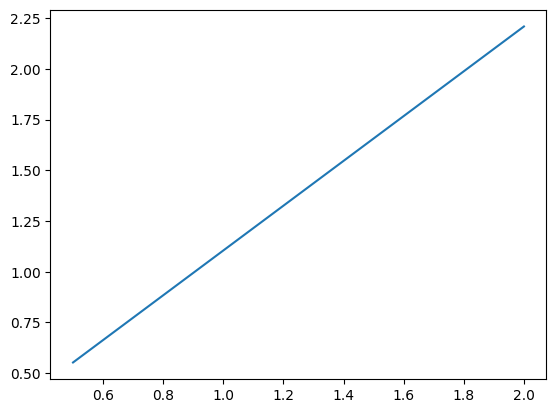

In [61]:
plt.plot(WT.s, np.sqrt(-WT.nl))
#plt.xlim(0.4,2.1)

# Get final results

## Decide on the list of atoms, phases, KEDFs and KEDF_options to use

In [62]:
phases = ['fcc', 'bcc', 'diamond']

In [63]:
atoms = ['Al','Si','Sn']

In [64]:
KEDFs = ['WT', 'SM']

In [65]:
KEDF_options_list = [ {}, { "rho0" : 0.3 } ]

## Plots

In [66]:
colors = ['k', 'k']
lw     = [3,3]
ls     = ['-',':']

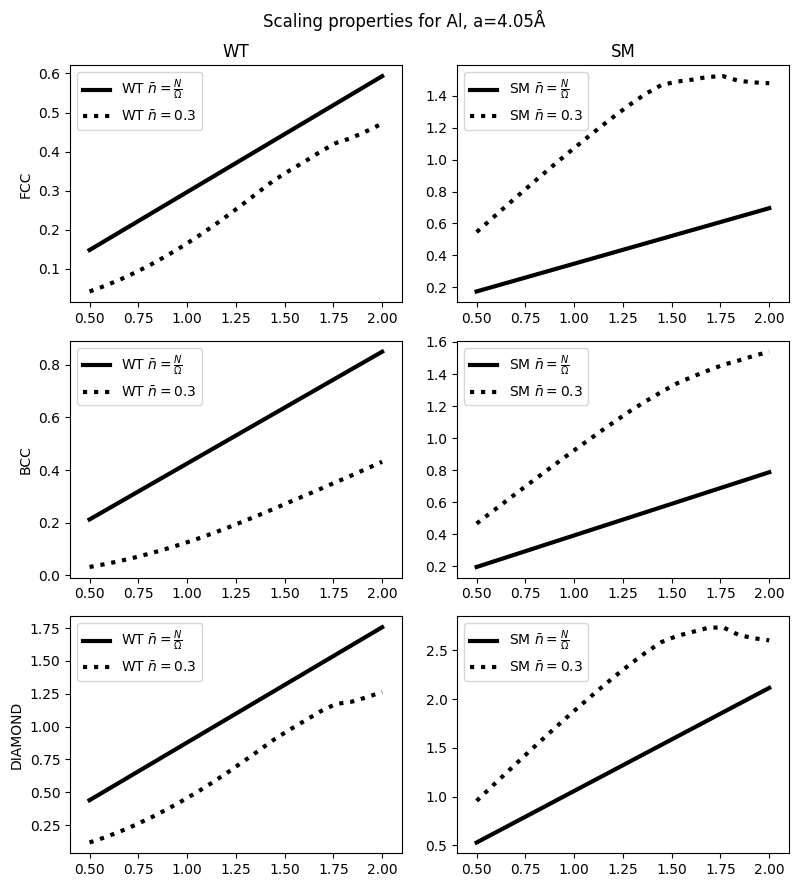

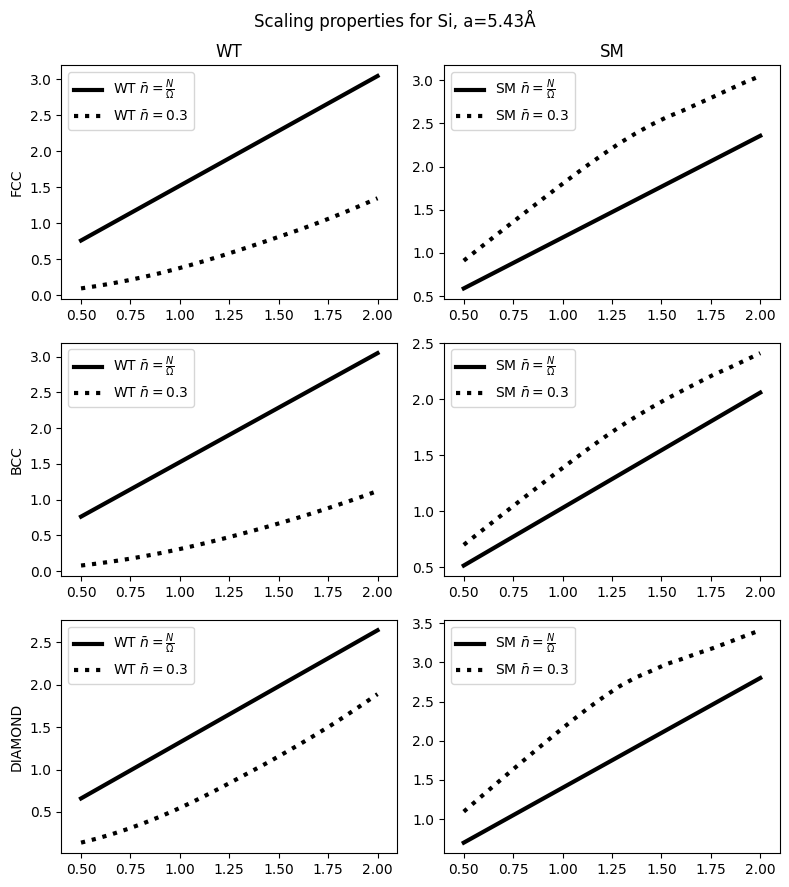

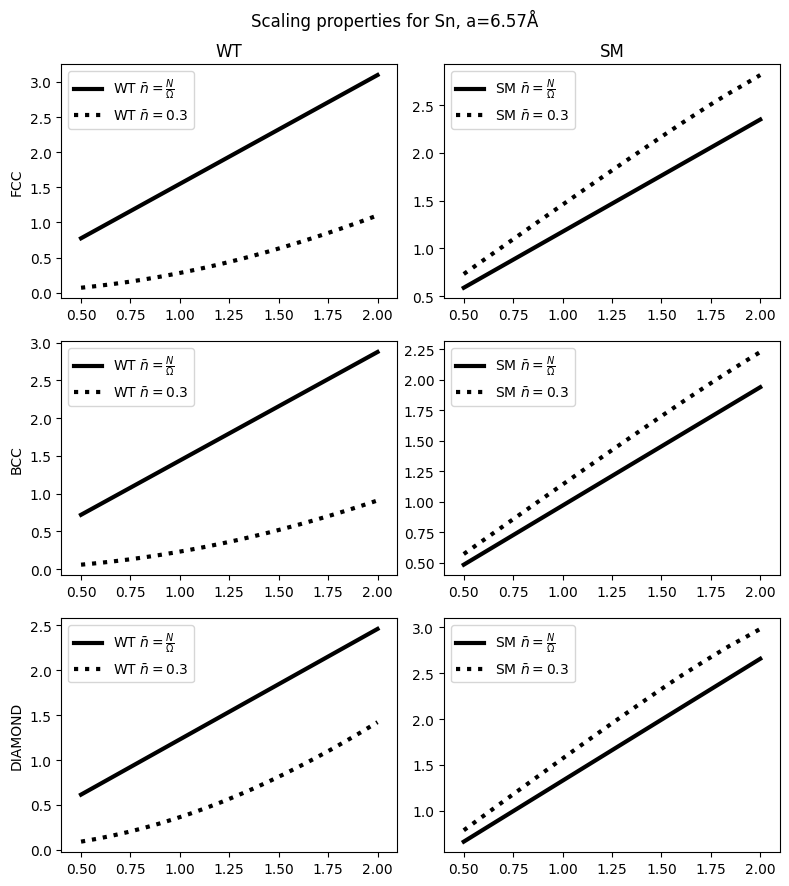

In [67]:
Virials = []
Plots = []
for l, atom in enumerate(atoms):
    lattice = None
    if atom=='Si':
        lattice=5.43
    if atom=='Sn':
        lattice=6.57
    if atom=='Al':
        lattice=4.05
    fig, axes = plt.subplots(len(phases), len(KEDFs), figsize=(4*len(KEDFs), 3*len(phases)))
    if len(phases) == 1:
        axes = [axes]
    if len(KEDF_options_list) == 1:
        axes = [[ax] for ax in axes]
    title = "Scaling properties for "+atom+", a="+str(lattice)+"Å"
    plt.suptitle(title)
    for i, phase in enumerate(phases):
        for j, KEDF in enumerate(KEDFs):
            ax = axes[i][j]
            ax.set_xlim(0.4,2.1)
            if i==0:
                ax.set_title(f"{KEDF}")
            if j==0:
                ax.set_ylabel(phase.upper())
            for k, options in enumerate(KEDF_options_list):
                if options == {}:
                    oprint = r"$\bar n = \frac{N}{\Omega}$"
                else:
                    oprint = r"$\bar n = 0.3$"
                FS = FunctionalScaling(atom_type=atom, phase = phase, KEDF=KEDF, KEDF_options=options, a=lattice)
                ax.plot(FS.s, np.sqrt(np.abs(FS.nl)), label=KEDF+" "+oprint, color=colors[k], ls=ls[k], lw=lw[k])
                Virials.append([atom, FS.kedf, oprint, FS.phase, FS.virial])
            ax.legend()
    plt.tight_layout()
    plt.savefig(atom+".pdf")
    #plt.show()
    

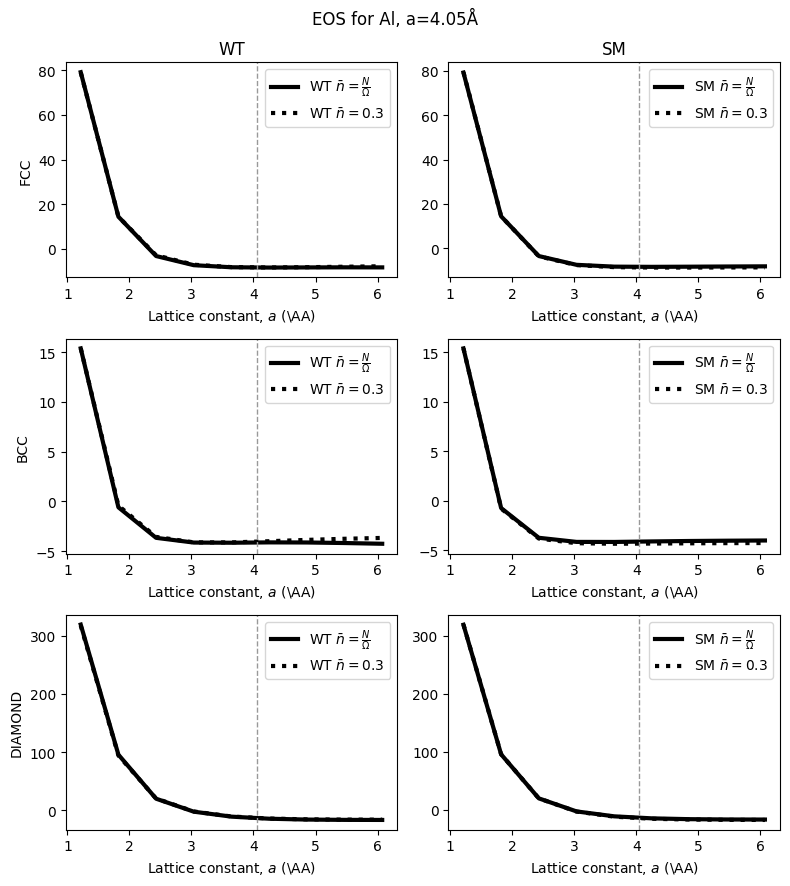

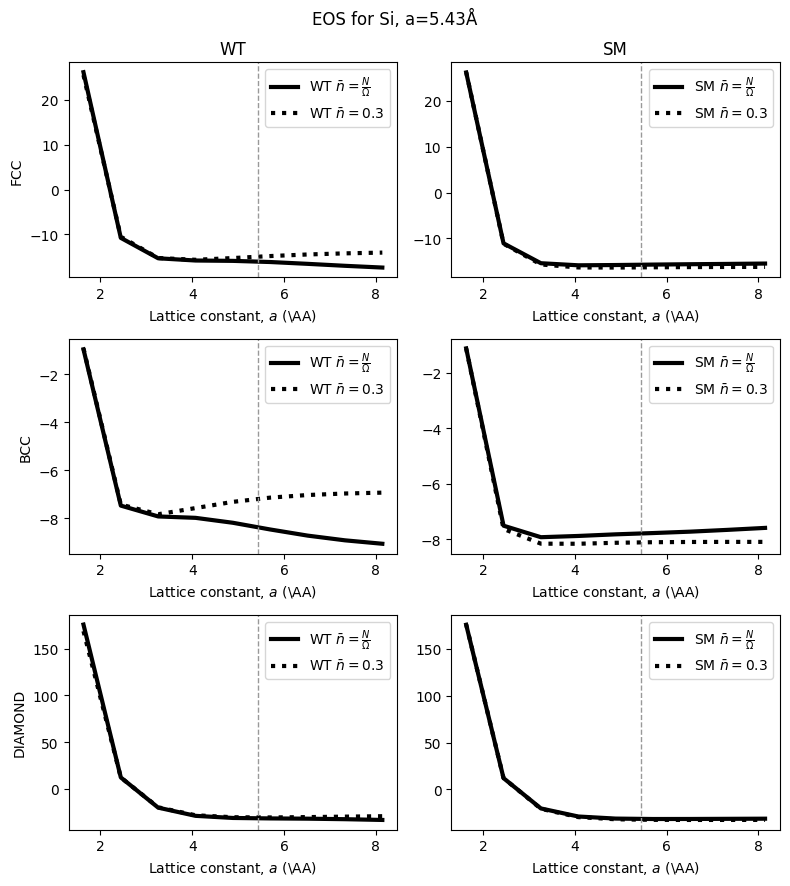

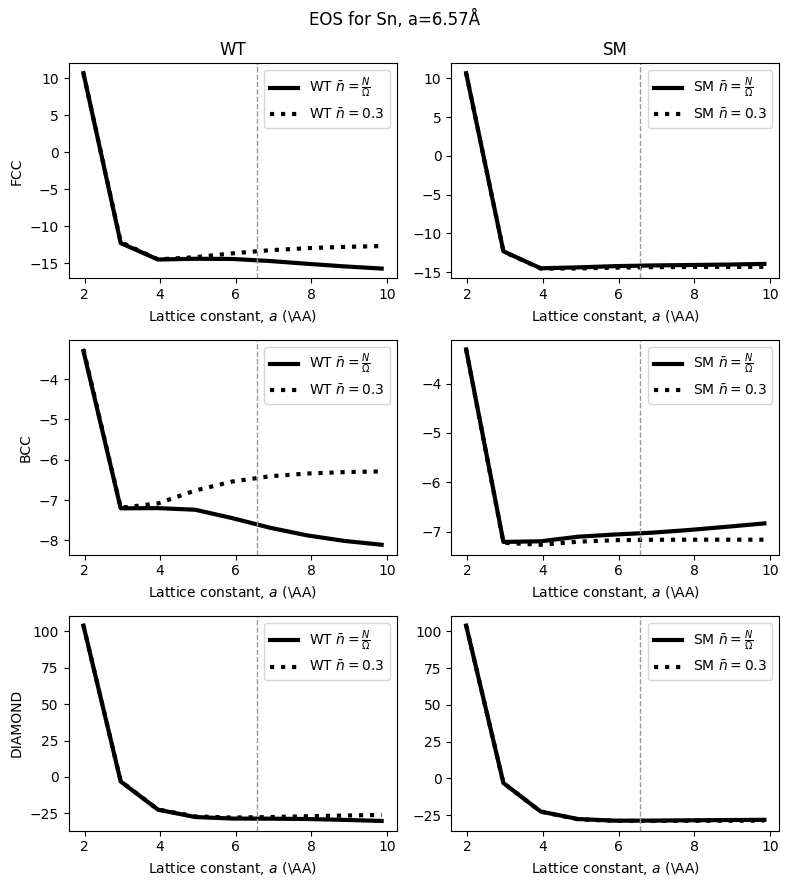

In [ ]:
EOS_plots = []
for l, atom in enumerate(atoms):
    lattice = None
    if atom=='Si':
        lattice=5.43
    if atom=='Sn':
        lattice=6.57
    if atom=='Al':
        lattice=4.05
    fig, axes = plt.subplots(len(phases), len(KEDFs), figsize=(4*len(KEDFs), 3*len(phases)))
    if len(phases) == 1:
        axes = [axes]
    if len(KEDF_options_list) == 1:
        axes = [[ax] for ax in axes]
    title = "EOS for "+atom+", a="+str(lattice)+"\u00c5"
    plt.suptitle(title)
    for i, phase in enumerate(phases):
        for j, KEDF in enumerate(KEDFs):
            ax = axes[i][j]
            if i==0:
                ax.set_title(f"{KEDF}")
            if j==0:
                ax.set_ylabel(phase.upper())
            for k, options in enumerate(KEDF_options_list):
                if options == {}:
                    oprint = r"$\bar n = \frac{N}{\Omega}$"
                else:
                    oprint = r"$\bar n = 0.3$"
                EOS = FunctionalEOS(atom_type=atom, phase = phase, KEDF=KEDF, KEDF_options=options, a=lattice)
                ax.plot(EOS.a_values, EOS.energies, label=KEDF+" "+oprint, color=colors[k], ls=ls[k], lw=lw[k])
            ax.axvline(lattice, color='0.6', lw=1, ls='--')
            ax.set_xlabel(r"Lattice constant, $a$ (\AA)")
            ax.legend()
    plt.tight_layout()
    plt.savefig(atom+"_EOS.pdf")
    #plt.show()



In [93]:
KEDFs = ['WT', 'WTE']

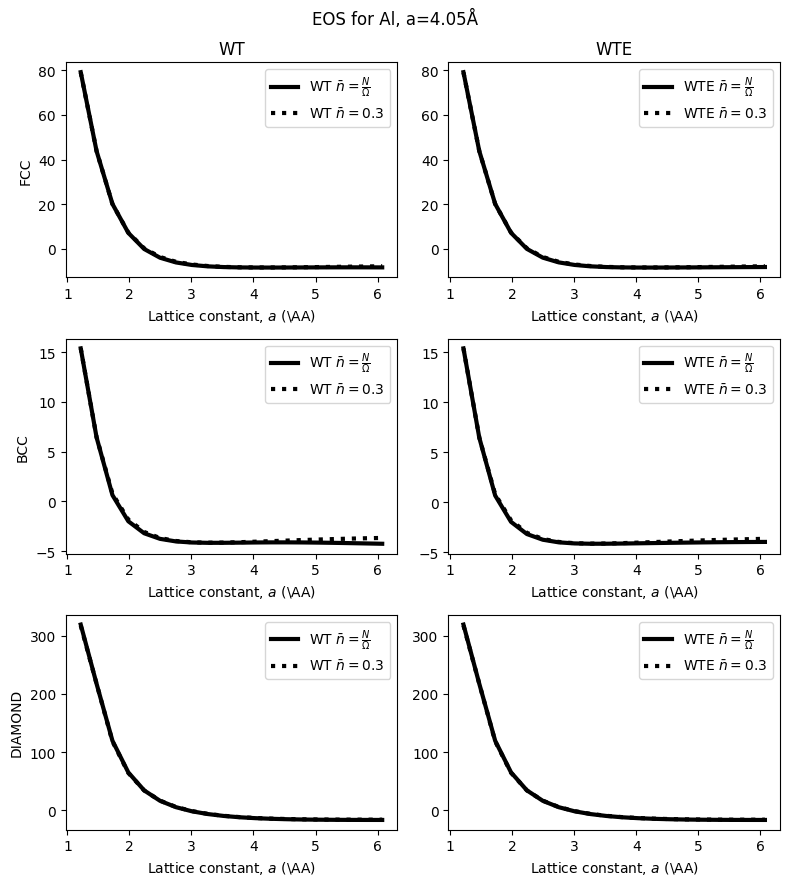

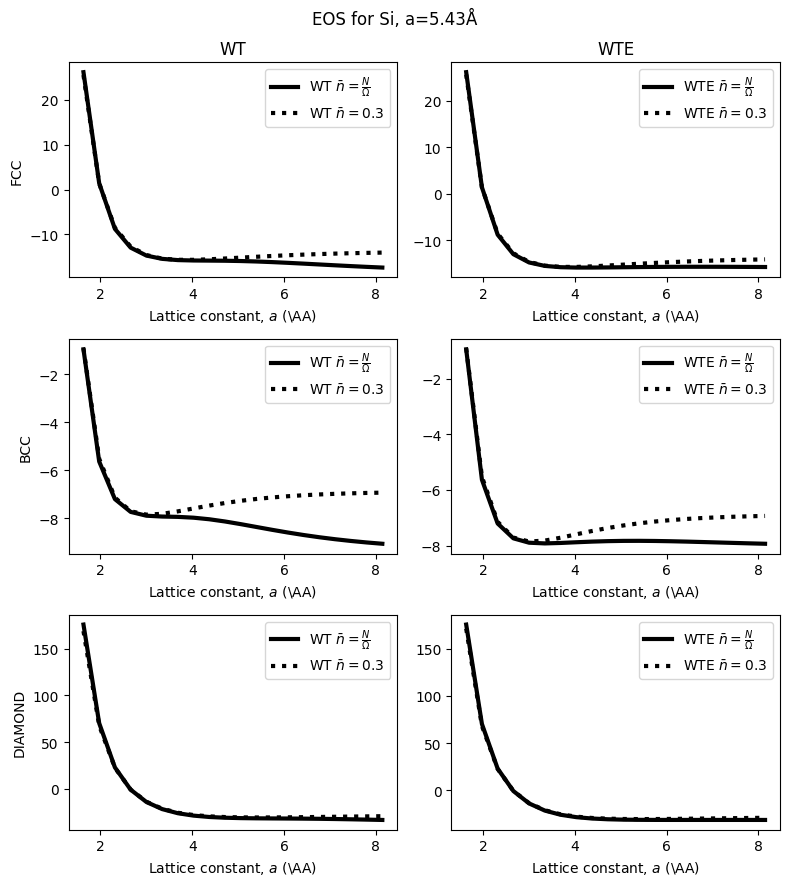

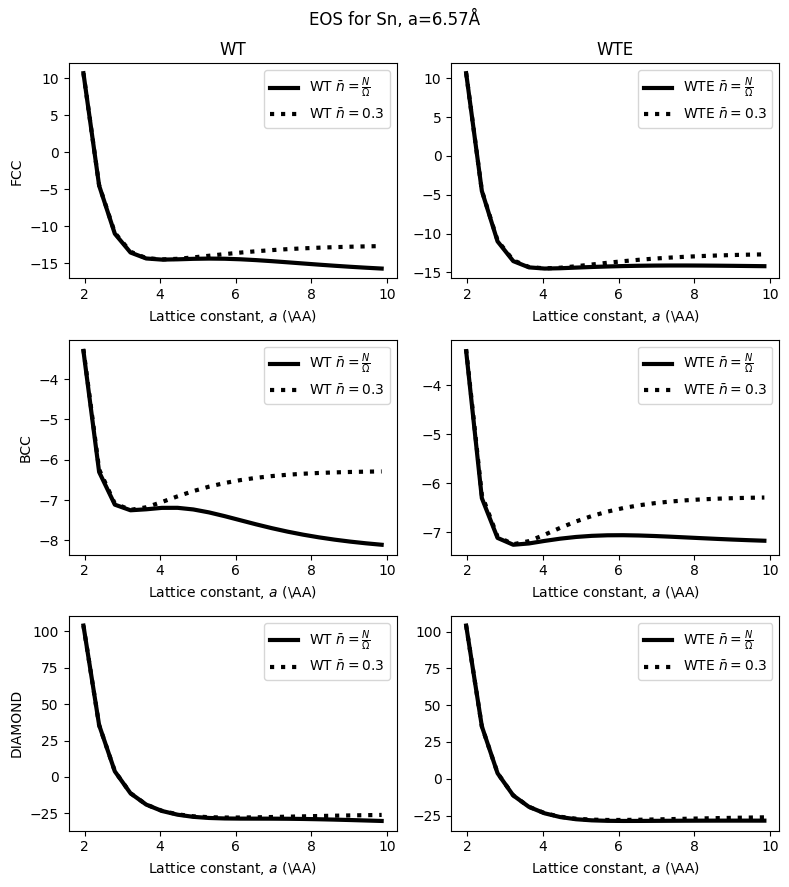

In [94]:
EOS_plots = []
for l, atom in enumerate(atoms):
    lattice = None
    if atom=='Si':
        lattice=5.43
    if atom=='Sn':
        lattice=6.57
    if atom=='Al':
        lattice=4.05
    fig, axes = plt.subplots(len(phases), len(KEDFs), figsize=(4*len(KEDFs), 3*len(phases)))
    if len(phases) == 1:
        axes = [axes]
    if len(KEDF_options_list) == 1:
        axes = [[ax] for ax in axes]
    title = "EOS for "+atom+", a="+str(lattice)+"\u00c5"
    plt.suptitle(title)
    for i, phase in enumerate(phases):
        for j, KEDF in enumerate(KEDFs):
            ax = axes[i][j]
            if i==0:
                ax.set_title(f"{KEDF}")
            if j==0:
                ax.set_ylabel(phase.upper())
            for k, options in enumerate(KEDF_options_list):
                if options == {}:
                    oprint = r"$\bar n = \frac{N}{\Omega}$"
                else:
                    oprint = r"$\bar n = 0.3$"
                EOS = FunctionalEOS(atom_type=atom, phase = phase, KEDF=KEDF, KEDF_options=options, a=lattice,a_range=[0.3,1.5],n_points=20)
                ax.plot(EOS.a_values, EOS.energies, label=KEDF+" "+oprint, color=colors[k], ls=ls[k], lw=lw[k])
            ax.set_xlabel(r"Lattice constant, $a$ (\AA)")
            ax.legend()
    plt.tight_layout()
    plt.savefig(atom+"_EOS.pdf")
    #plt.show()



## Table

In [69]:
import pandas as pd
from IPython.display import Markdown
df = pd.DataFrame(Virials, columns=["Element", "KEDF", "Params", "Phase", "Virial"])
Markdown(df.to_latex())

\begin{tabular}{lllllr}
\toprule
 & Element & KEDF & Params & Phase & Virial \\
\midrule
0 & Al & WT & $\bar n = \frac{N}{\Omega}$ & fcc & 2.000000 \\
1 & Al & WT & $\bar n = 0.3$ & fcc & 3.820031 \\
2 & Al & SM & $\bar n = \frac{N}{\Omega}$ & fcc & 2.000000 \\
3 & Al & SM & $\bar n = 0.3$ & fcc & 1.864517 \\
4 & Al & WT & $\bar n = \frac{N}{\Omega}$ & bcc & 2.000000 \\
5 & Al & WT & $\bar n = 0.3$ & bcc & 3.892031 \\
6 & Al & SM & $\bar n = \frac{N}{\Omega}$ & bcc & 2.000000 \\
7 & Al & SM & $\bar n = 0.3$ & bcc & 1.904688 \\
8 & Al & WT & $\bar n = \frac{N}{\Omega}$ & diamond & 2.000000 \\
9 & Al & WT & $\bar n = 0.3$ & diamond & 3.789706 \\
10 & Al & SM & $\bar n = \frac{N}{\Omega}$ & diamond & 2.000000 \\
11 & Al & SM & $\bar n = 0.3$ & diamond & 1.861069 \\
12 & Si & WT & $\bar n = \frac{N}{\Omega}$ & fcc & 2.000000 \\
13 & Si & WT & $\bar n = 0.3$ & fcc & 3.922122 \\
14 & Si & SM & $\bar n = \frac{N}{\Omega}$ & fcc & 2.000000 \\
15 & Si & SM & $\bar n = 0.3$ & fcc & 1.921574 \\
16 & Si & WT & $\bar n = \frac{N}{\Omega}$ & bcc & 2.000000 \\
17 & Si & WT & $\bar n = 0.3$ & bcc & 3.936692 \\
18 & Si & SM & $\bar n = \frac{N}{\Omega}$ & bcc & 2.000000 \\
19 & Si & SM & $\bar n = 0.3$ & bcc & 1.934807 \\
20 & Si & WT & $\bar n = \frac{N}{\Omega}$ & diamond & 2.000000 \\
21 & Si & WT & $\bar n = 0.3$ & diamond & 3.903422 \\
22 & Si & SM & $\bar n = \frac{N}{\Omega}$ & diamond & 2.000000 \\
23 & Si & SM & $\bar n = 0.3$ & diamond & 1.889476 \\
24 & Sn & WT & $\bar n = \frac{N}{\Omega}$ & fcc & 2.000000 \\
25 & Sn & WT & $\bar n = 0.3$ & fcc & 3.987649 \\
26 & Sn & SM & $\bar n = \frac{N}{\Omega}$ & fcc & 2.000000 \\
27 & Sn & SM & $\bar n = 0.3$ & fcc & 1.981572 \\
28 & Sn & WT & $\bar n = \frac{N}{\Omega}$ & bcc & 2.000000 \\
29 & Sn & WT & $\bar n = 0.3$ & bcc & 3.989229 \\
30 & Sn & SM & $\bar n = \frac{N}{\Omega}$ & bcc & 2.000000 \\
31 & Sn & SM & $\bar n = 0.3$ & bcc & 1.985892 \\
32 & Sn & WT & $\bar n = \frac{N}{\Omega}$ & diamond & 2.000000 \\
33 & Sn & WT & $\bar n = 0.3$ & diamond & 3.985748 \\
34 & Sn & SM & $\bar n = \frac{N}{\Omega}$ & diamond & 2.000000 \\
35 & Sn & SM & $\bar n = 0.3$ & diamond & 1.975795 \\
\bottomrule
\end{tabular}


In [70]:
WT = FunctionalScaling(atom_type='Al', phase = 'fcc', KEDF='WT', a=4.05)

In [71]:
WT_adhoc = FunctionalScaling(atom_type='Al', phase = 'fcc', KEDF='WT', a=4.05, KEDF_options={"rho0" : 0.3})

In [72]:
SM = FunctionalScaling(atom_type='Al', phase = 'fcc', KEDF='SM', a=4.05)

In [73]:
SM_adhoc = FunctionalScaling(atom_type='Al', phase = 'fcc', KEDF='SM', a=4.05, KEDF_options={"rho0" : 0.3})

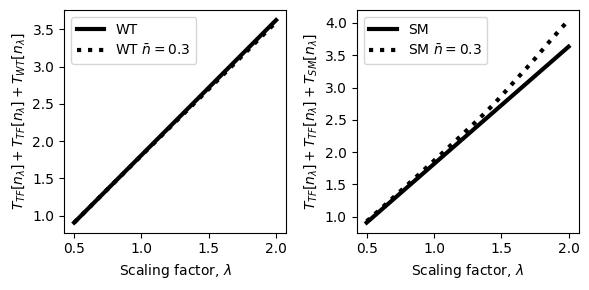

In [74]:
fig, (ax_WT, ax_SM) = plt.subplots(1,2, figsize = (6, 3))
ax_WT.plot(WT.s, np.sqrt(WT.nl+WT.tfvw), color='k', lw=3, ls='-', label="WT")
ax_WT.plot(WT_adhoc.s, np.sqrt(WT_adhoc.tfvw+WT_adhoc.nl), color='k', lw=3, ls=':', label=r"WT $\bar n = 0.3$")
ax_SM.plot(SM.s, np.sqrt(SM.nl+SM.tfvw), color='k', lw=3, ls='-', label="SM")
ax_SM.plot(SM_adhoc.s, np.sqrt(SM_adhoc.tfvw+SM_adhoc.nl), color='k', lw=3, ls=':', label=r"SM $\bar n = 0.3$")
ax_WT.set_xlabel(r"Scaling factor, $\lambda$")
ax_SM.set_xlabel(r"Scaling factor, $\lambda$")
ax_WT.set_ylabel(r"$T_{TF}[n_\lambda]+T_{TF}[n_\lambda]+T_{WT}[n_\lambda]$")
ax_SM.set_ylabel(r"$T_{TF}[n_\lambda]+T_{TF}[n_\lambda]+T_{SM}[n_\lambda]$")
ax_WT.legend()
ax_SM.legend()
plt.tight_layout()
plt.savefig("WT-SM_Al_total_KEDF.pdf")